# COVID-19 Global Trends — Exploratory Data Analysis
**Level:** Beginner · **Tools:** Python, Pandas, Matplotlib, Seaborn

**Goal:** explore how COVID-19 spread across 198 countries (Jan 2020 – Apr 2022), which countries were hit hardest, and how the pandemic moved in waves.

**Dataset:** [datasets/covid-19](https://github.com/datasets/covid-19) (Johns Hopkins CSSE, aggregated by country, daily cumulative counts).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("data/countries-aggregated.csv", parse_dates=["Date"])
df.head()

,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


## 1. Data quality check

In [2]:
print(df.shape)
print(df.dtypes)
print("Missing values:\n", df.isna().sum())
print("Date range:", df.Date.min().date(), "to", df.Date.max().date(), "| Countries:", df.Country.nunique())

(161568, 5)
Date         datetime64[us]
Country                 str
Confirmed             int64
Recovered             int64
Deaths                int64
dtype: object
Missing values:
 Date         0
Country      0
Confirmed    0
Recovered    0
Deaths       0
dtype: int64
Date range: 2020-01-22 to 2022-04-16 | Countries: 198


The data is clean: no missing values, one row per country per day, cumulative counts. `Recovered` stopped being reported in Aug 2021, so this analysis focuses on **Confirmed** and **Deaths**.

In [3]:
# Daily new cases/deaths from cumulative counts (negative corrections clipped to 0)
df = df.sort_values(["Country","Date"])
df["NewCases"]  = df.groupby("Country")["Confirmed"].diff().clip(lower=0).fillna(0)
df["NewDeaths"] = df.groupby("Country")["Deaths"].diff().clip(lower=0).fillna(0)
latest = df[df.Date == df.Date.max()].copy()
latest["CFR_%"] = (latest.Deaths / latest.Confirmed * 100).round(2)
print(f"Global confirmed: {latest.Confirmed.sum():,.0f} | Global deaths: {latest.Deaths.sum():,.0f} | Global CFR: {latest.Deaths.sum()/latest.Confirmed.sum()*100:.2f}%")

Global confirmed: 504,155,459 | Global deaths: 6,197,159 | Global CFR: 1.23%


## 2. Global spread over time

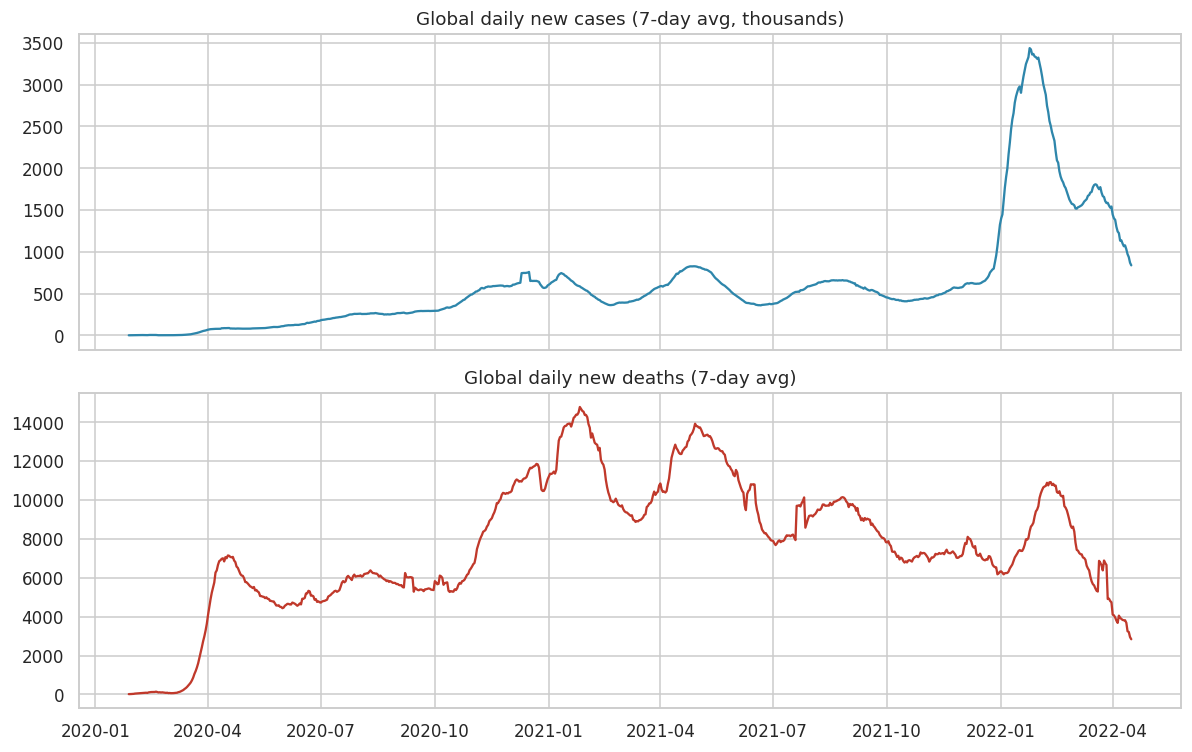

In [4]:
glob = df.groupby("Date")[["NewCases","NewDeaths"]].sum().rolling(7).mean()
fig, ax = plt.subplots(2,1, figsize=(11,7), sharex=True)
ax[0].plot(glob.index, glob.NewCases/1e3, color="#2E86AB"); ax[0].set_title("Global daily new cases (7-day avg, thousands)")
ax[1].plot(glob.index, glob.NewDeaths, color="#C0392B"); ax[1].set_title("Global daily new deaths (7-day avg)")
plt.tight_layout(); plt.savefig("images/global_waves.png", bbox_inches="tight"); plt.show()

## 3. Most affected countries

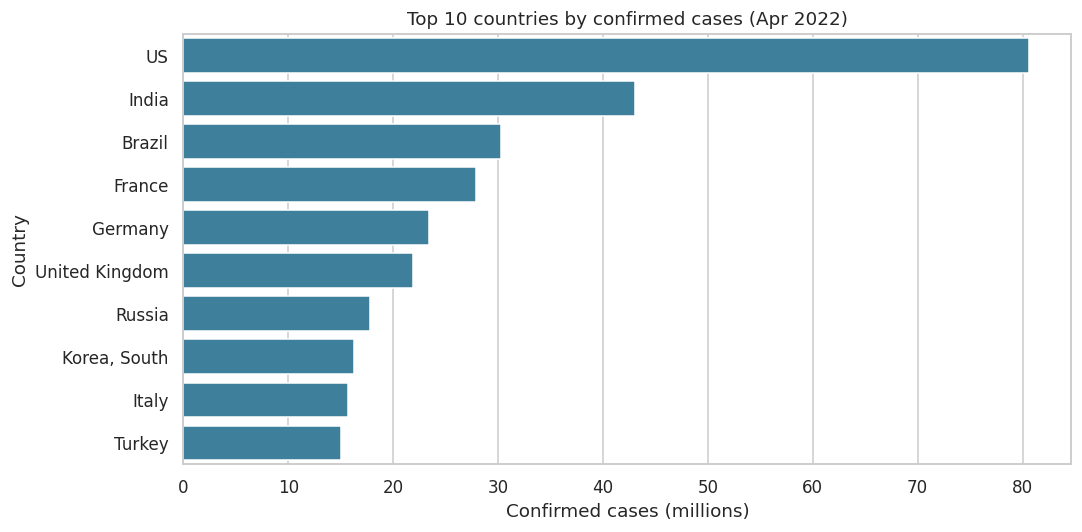

,Country,Confirmed,Deaths,CFR_%
150143,US,80625120,988609,1.23
66095,India,43042097,521751,1.21
20399,Brazil,30250077,662185,2.19
52223,France,27874269,145159,0.52
55487,Germany,23416663,132942,0.57
153407,United Kingdom,21916961,172014,0.78
119135,Russia,17801103,365774,2.05
76703,"Korea, South",16305752,21092,0.13
70991,Italy,15659835,161602,1.03
149327,Turkey,14991669,98551,0.66


In [5]:
top = latest.nlargest(10, "Confirmed")[["Country","Confirmed","Deaths","CFR_%"]]
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=top, y="Country", x=top.Confirmed/1e6, color="#2E86AB", ax=ax)
ax.set_xlabel("Confirmed cases (millions)"); ax.set_title("Top 10 countries by confirmed cases (Apr 2022)")
plt.tight_layout(); plt.savefig("images/top10_confirmed.png", bbox_inches="tight"); plt.show()
top

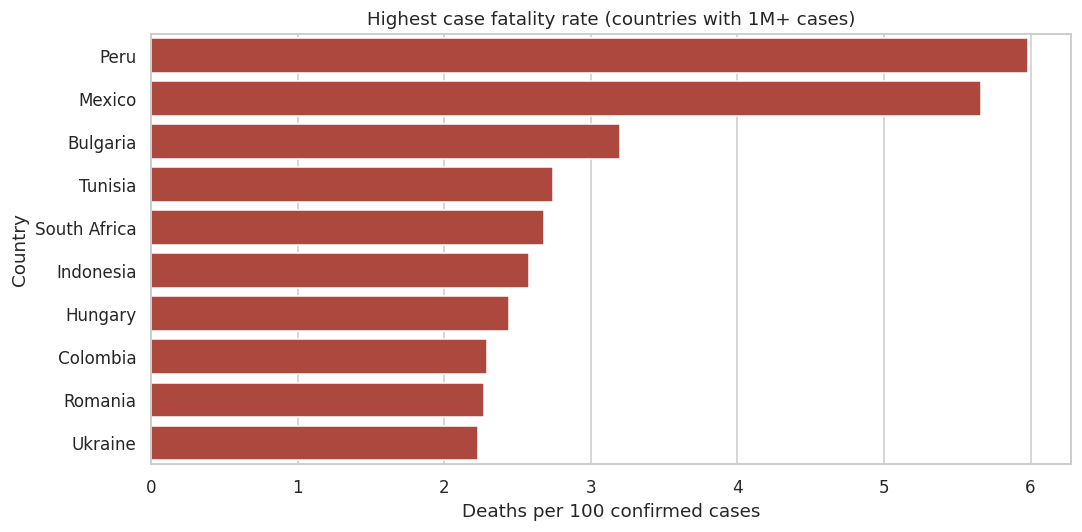

,Country,Confirmed,Deaths,CFR_%
114239,Peru,3555139,212619,5.98
95471,Mexico,5726668,323938,5.66
22031,Bulgaria,1149225,36782,3.20
148511,Tunisia,1038668,28509,2.74
133823,South Africa,3740398,100144,2.68
66911,Indonesia,6039266,155844,2.58
64463,Hungary,1879480,45865,2.44
31823,Colombia,6089540,139745,2.29
118319,Romania,2881322,65331,2.27
151775,Ukraine,5040518,112459,2.23


In [6]:
# Case fatality rate among countries with 1M+ cases
big = latest[latest.Confirmed >= 1_000_000].nlargest(10, "CFR_%")[["Country","Confirmed","Deaths","CFR_%"]]
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=big, y="Country", x="CFR_%", color="#C0392B", ax=ax)
ax.set_title("Highest case fatality rate (countries with 1M+ cases)"); ax.set_xlabel("Deaths per 100 confirmed cases")
plt.tight_layout(); plt.savefig("images/highest_cfr.png", bbox_inches="tight"); plt.show()
big

## 4. India vs. US vs. Brazil — how the waves differed

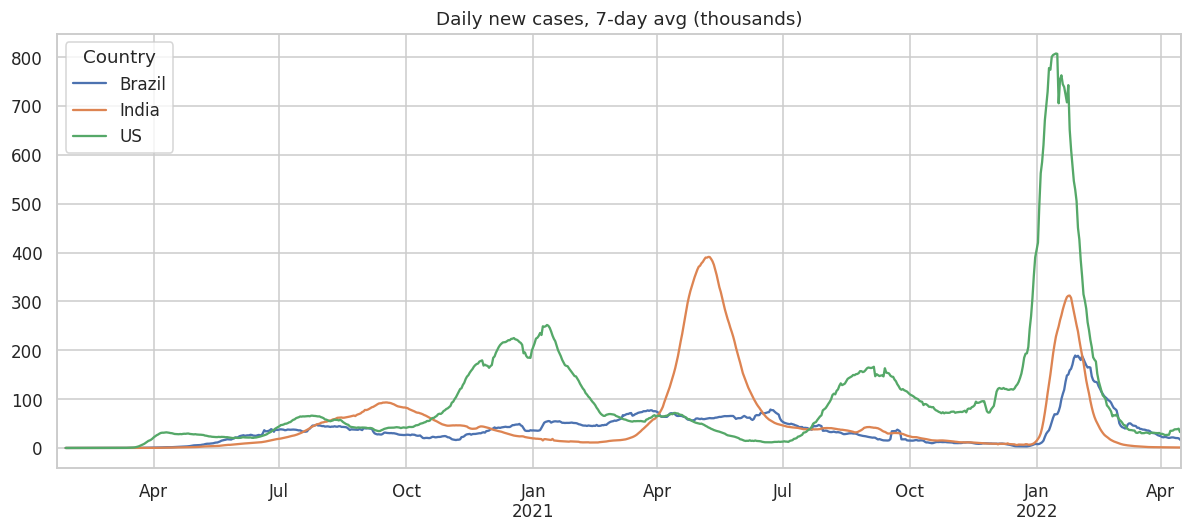

,Peak date,Peak 7-day avg
Country,,
Brazil,2022-01-29,189227.0
India,2021-05-08,391232.0
US,2022-01-15,807718.0


In [7]:
sel = ["India","US","Brazil"]
w = df[df.Country.isin(sel)].pivot(index="Date", columns="Country", values="NewCases").rolling(7).mean()
ax = (w/1e3).plot(figsize=(11,5), title="Daily new cases, 7-day avg (thousands)")
ax.set_xlabel(""); plt.tight_layout(); plt.savefig("images/india_us_brazil.png", bbox_inches="tight"); plt.show()
peaks = w.idxmax().to_frame("Peak date").assign(**{"Peak 7-day avg": w.max().round(0)})
peaks

## 5. Monthly heatmap of new cases (top 8 countries)

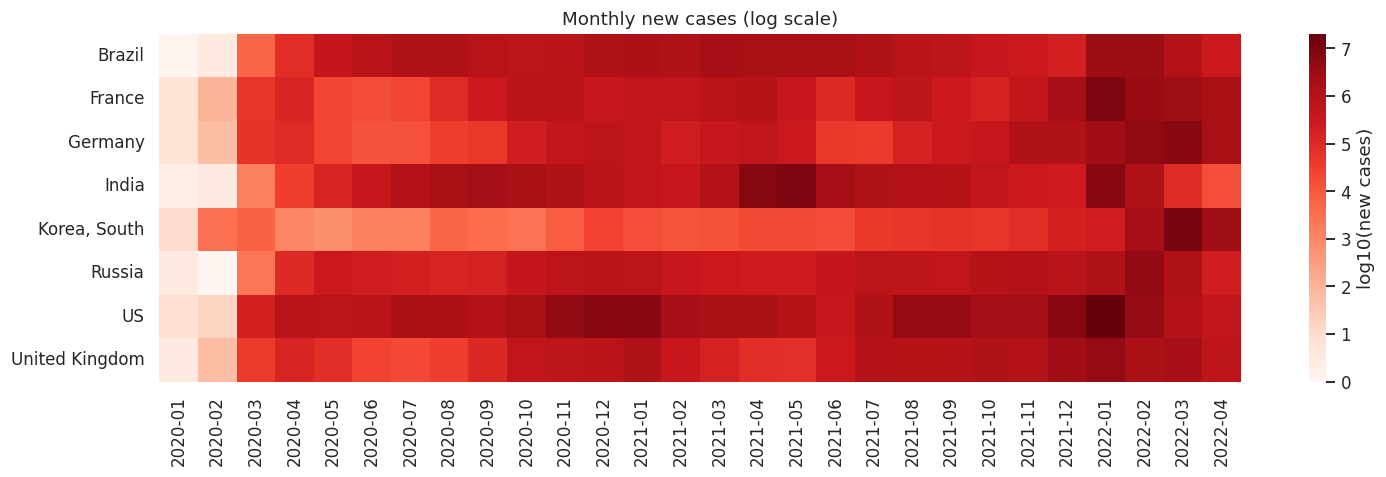

In [8]:
top8 = latest.nlargest(8, "Confirmed").Country
m = (df[df.Country.isin(top8)].assign(Month=lambda x: x.Date.dt.to_period("M").astype(str))
       .groupby(["Country","Month"]).NewCases.sum().unstack())
plt.figure(figsize=(14,4.5))
sns.heatmap(np.log10(m+1), cmap="Reds", cbar_kws={"label":"log10(new cases)"})
plt.title("Monthly new cases (log scale)"); plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.savefig("images/monthly_heatmap.png", bbox_inches="tight"); plt.show()

## Key insights
1. **Cases and deaths peaked at different times.** Global daily deaths peaked in **Jan 2021** (~14.8K/day, 7-day avg). Daily cases peaked a year later in **Jan 2022** (~3.4M/day) during Omicron, which spread far more but was much less deadly per case.
2. The **US (80.6M), India (43.0M) and Brazil (30.3M)** recorded the most confirmed cases. Their peaks came at different times: India in **May 2021** (Delta, ~391K/day), and the US and Brazil in **Jan 2022** (Omicron).
3. **Case fatality rate varies widely.** Among countries with 1M+ cases, **Peru (5.98%)** and **Mexico (5.66%)** are highest, against a global **1.23%**. That reflects testing levels and health-system capacity as well as how deadly the virus was.
4. **South Korea** had 16.3M cases with a CFR of only **0.13%**, a sign of mass testing and a late, mostly Omicron-driven epidemic.

*Limitations: confirmed counts depend on testing; `Recovered` stopped being reported in 2021.*